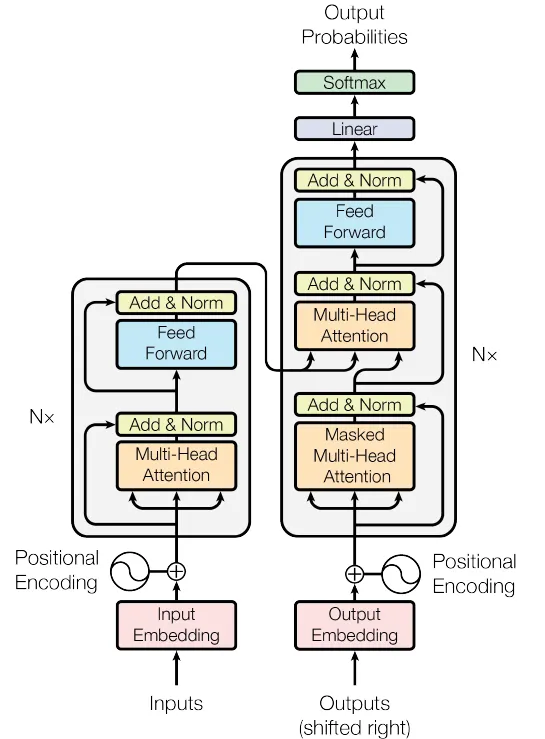

In [97]:
import torch
import torch.nn as nn
import math
import copy
import torch.utils.data as data
import torch.optim as optim

In [98]:
class MultiHeadAttention(nn.Module):
  def __init__(self,d_model,num_heads):
    super(MultiHeadAttention, self).__init__()

    # Calculate d_k value

    assert d_model % num_heads==0
    self.d_model=d_model
    self.num_heads=num_heads
    self.d_k=d_model//num_heads         # "//" for integer d_k

    #Weight metrics shape declare

    self.Wq=nn.Linear(d_model,d_model)
    self.Wv=nn.Linear(d_model,d_model)
    self.Wk=nn.Linear(d_model,d_model)
    self.Wo=nn.Linear(d_model,d_model)
#-----------------------------------------------------------------------------------------------------------------------------------------------------

  def scaled_dot_product(self,Q,K,V,mask=None):
    attention_score=torch.matmul(Q,K.transpose(-2,-1))/math.sqrt(self.d_k)
    if mask is not None:
      attention_scores = attention_score.masked_fill(mask == 0, -1e9)
      torch.finfo(attention_score.dtype).min
    attention_probability=torch.softmax(attention_score,dim=-1)
    output=torch.matmul(attention_probability,V)
    return output
#-----------------------------------------------------------------------------------------------------------------------------------------------------
  def split_head(self,x):                                                             # (একটি বড় embedding representation-কে একাধিক attention head-এর
                                                                                      # জন্য আলাদা dimension-এ ভাগ করা)
    batch_size,seq_length,d_model=x.size()                                            # X shape(batch, sequence, heads, head_dimension)
    return x.view(batch_size, seq_length, self.num_heads, self.d_k).transpose(1, 2)   # X shape now (batch, heads, sequence, head_dimension)
                                                                                      # কারণ আমরা প্রতিটি head-এর জন্য আলাদা attention calculation করতে চাই।
#-----------------------------------------------------------------------------------------------------------------------------------------------------
    # আমাদের original Transformer representation (batch, sequence, d_model) দরকার:
    # contiguous() এটি memory layout ঠিক করে যাতে পরবর্তীতে view() safely ব্যবহার করা যায়।
    # transpose() করার পরে tensor-এর memory arrangement পরিবর্তিত হতে পারে;
    # contiguous() সেটিকে memory-তে contiguous format-এ নিয়ে আসে।
  def combine_heads(self, x):
    batch_size, num_heads, seq_length, d_k = x.size()

    return x.transpose(1, 2).contiguous().view(
        batch_size,
        seq_length,
        self.d_model
    )
#-----------------------------------------------------------------------------------------------------------------------------------------------------

  def forward(self,Q,K,V,mask=None):
    Q=self.split_head(self.Wq(Q))                                                 # Q=X*WQ​, split_head() Q-কে multiple heads-এ ভাগ করা। Q shape ---> (batch, heads, seq, d_k)
    K=self.split_head(self.Wk(K))
    V=self.split_head(self.Wv(V))
    attention=self.scaled_dot_product(Q,K,V,mask)
    output=self.Wo(self.combine_heads(attention))
    return output



In [99]:
class positionFeedForward(nn.Module):
  def __init__(self,d_model,d_ff,dropout):
    super().__init__()
    self.fc1=nn.Linear(d_model,d_ff)
    self.fc2=nn.Linear(d_ff,d_model)
    self.relu=nn.ReLU()
    self.dropout=nn.Dropout(dropout)
  def forward(self,x):
    out1=self.fc1(x)
    out1=self.relu(out1)
    out1 = self.dropout(out1) # Apply dropout
    out2=self.fc2(out1)
    out2=self.relu(out2)
    return out2

In [100]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_seq_length):
        super().__init__()

        pe = torch.zeros(max_seq_length, d_model)

        position = torch.arange(
            0, max_seq_length, dtype=torch.float
        ).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2).float()* (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)

        self.register_buffer("pe", pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

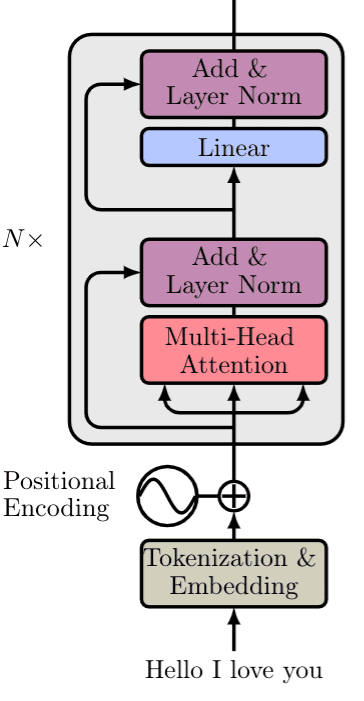

In [101]:
class EncoderLayer(nn.Module):
  def __init__(self,d_model,num_heads,d_ff,dropout):
    super().__init__()
    self.self_attention=MultiHeadAttention(d_model,num_heads)  # Renamed for consistency with forward
    self.feedforward=positionFeedForward(d_model,d_ff,dropout)          # Pass dropout argument
    self.norm1=nn.LayerNorm(d_model)                            # Declare 1st Normalization layer
    self.norm2=nn.LayerNorm(d_model)                            # Declare 2nd Normalization layer
    self.dropout=nn.Dropout(dropout)                            # Declare Dropout layer

  def forward(self,x,mask):
    attention_output=self.self_attention(x,x,x,mask) # Use self.self_attention
    x=self.norm1(x+self.dropout(attention_output))              # Input + MultiHeadAttention Output into the Normalization Layer1
    ff_output=self.feedforward(x)                               # Linear Operation
    x = self.norm2(x + self.dropout(ff_output))                 # 2nd Normalize layer
    return x

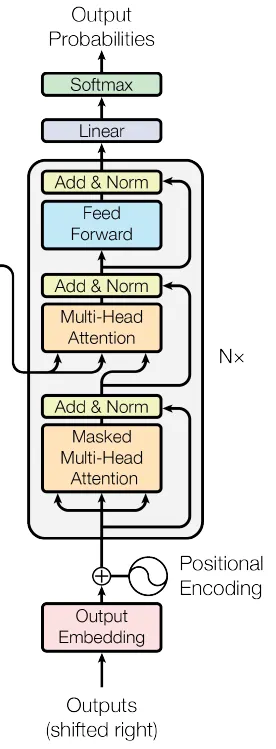


In [102]:
class DecoderLayer(nn.Module):
  def __init__(self,d_model,num_heads,d_ff,dropout):
    super().__init__()

    self.self_attention=MultiHeadAttention(d_model,num_heads)
    self.cross_attention=MultiHeadAttention(d_model,num_heads)
    self.feed_forward=positionFeedForward(d_model,d_ff,dropout)
    self.norm1=nn.LayerNorm(d_model)
    self.norm2=nn.LayerNorm(d_model)
    self.norm3=nn.LayerNorm(d_model)
    self.dropout=nn.Dropout(dropout)

  def forward(self,x,encoder_output,src_mask,target_mask):

    attention_output=self.self_attention(x,x,x,target_mask)
    x=self.norm1(x+self.dropout(attention_output))
    attention_output=self.cross_attention(x,encoder_output,encoder_output,src_mask)
    x=self.norm2(x+self.dropout(attention_output))
    ff_output=self.feed_forward(x)
    x=self.norm3(x+self.dropout(self.feed_forward(x)))
    return x

In [103]:
class Transformer(nn.Module):
  def __init__(self,src_vocab_size,trgt_vocab_size,d_model,num_heads,num_layers,d_ff,max_seq_length,dropout):
    super().__init__()

    self.encoder_embedding=nn.Embedding(src_vocab_size,d_model)
    self.decoder_embedding=nn.Embedding(trgt_vocab_size,d_model)
    self.positional_encoding=PositionalEncoding(d_model,max_seq_length)
    self.encoder_layers=nn.ModuleList([EncoderLayer(d_model,num_heads,d_ff,dropout) for _ in range(num_layers)])
    self.decoder_layers=nn.ModuleList([DecoderLayer(d_model,num_heads,d_ff,dropout) for _ in range(num_layers)])

    self.fc=nn.Linear(d_model,trgt_vocab_size)
    self.dropout=nn.Dropout(dropout)

  def generate_mask(self, src, tgt):
    src_mask = (src != 0).unsqueeze(1).unsqueeze(2)
    tgt_mask = (tgt != 0).unsqueeze(1).unsqueeze(3)
    seq_length = tgt.size(1)
    nopeak_mask = (1 - torch.triu(torch.ones(1, seq_length, seq_length), diagonal=1)).bool()
    tgt_mask = tgt_mask & nopeak_mask
    return src_mask, tgt_mask
  def forward(self,src,target):
    src_mask,trgt_mask=self.generate_mask(src,target)
    src_mask, tgt_mask = self.generate_mask(src, target)
    src_embedded = self.dropout(self.positional_encoding(self.encoder_embedding(src)))
    tgt_embedded = self.dropout(self.positional_encoding(self.decoder_embedding(target)))
    enc_output=src_embedded
    for enc_layer in self.encoder_layers:
      enc_output=enc_layer(enc_output,src_mask)
    dec_output=tgt_embedded
    for dec_layer in self.decoder_layers:
        dec_output = dec_layer(dec_output, enc_output, src_mask, tgt_mask)

    output = self.fc(dec_output)
    return output

In [104]:
src_vocab_size = 5000
tgt_vocab_size = 5000
d_model = 512
num_heads = 8
num_layers = 6
d_ff = 2048
max_seq_length = 100
dropout = 0.1

transformer = Transformer(src_vocab_size, tgt_vocab_size, d_model, num_heads, num_layers, d_ff, max_seq_length, dropout)

# Generate random sample data
src_data = torch.randint(1, src_vocab_size, (64, max_seq_length))  # (batch_size, seq_length)
tgt_data = torch.randint(1, tgt_vocab_size, (64, max_seq_length))  # (batch_size, seq_length)

In [105]:
criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = optim.Adam(transformer.parameters(), lr=0.0001, betas=(0.9, 0.98), eps=1e-9)

transformer.train()

for epoch in range(100):
    optimizer.zero_grad()
    output = transformer(src_data, tgt_data[:, :-1])
    loss = criterion(output.contiguous().view(-1, tgt_vocab_size), tgt_data[:, 1:].contiguous().view(-1))
    loss.backward()
    optimizer.step()
    print(f"Epoch: {epoch+1}, Loss: {loss.item()}")

Epoch: 1, Loss: 8.670421600341797
Epoch: 2, Loss: 8.55892276763916
Epoch: 3, Loss: 8.495292663574219
Epoch: 4, Loss: 8.446653366088867
Epoch: 5, Loss: 8.40068531036377
Epoch: 6, Loss: 8.348701477050781
Epoch: 7, Loss: 8.30185604095459
Epoch: 8, Loss: 8.233770370483398
Epoch: 9, Loss: 8.16966438293457
Epoch: 10, Loss: 8.109193801879883
Epoch: 11, Loss: 8.051115989685059
Epoch: 12, Loss: 7.9833550453186035
Epoch: 13, Loss: 7.918701648712158
Epoch: 14, Loss: 7.853208541870117
Epoch: 15, Loss: 7.784149646759033
Epoch: 16, Loss: 7.717835903167725
Epoch: 17, Loss: 7.647894382476807
Epoch: 18, Loss: 7.584279537200928
Epoch: 19, Loss: 7.5085768699646
Epoch: 20, Loss: 7.440827369689941
Epoch: 21, Loss: 7.373297691345215
Epoch: 22, Loss: 7.305068016052246
Epoch: 23, Loss: 7.23829984664917
Epoch: 24, Loss: 7.171595096588135
Epoch: 25, Loss: 7.097977638244629
Epoch: 26, Loss: 7.029673099517822
Epoch: 27, Loss: 6.964578628540039
Epoch: 28, Loss: 6.896036624908447
Epoch: 29, Loss: 6.835634231567383
